# Task 6: 1-, 5-, 10-day VaR & square-root-of-time scaling

In [22]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_RETURNS = "data/returns_clean.csv"
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

# ── Sample period ─────────────────────────────────────────────────────────────
SAMPLE_START = "2017-01-01"
SAMPLE_END   = "2026-03-31"

# ── Portfolio setup ────────────────────────────
PORTFOLIO_VALUE = 1_000_000
TRADING_DAYS    = 252
ALPHAS          = [0.99, 0.975]   # confidence levels

WEIGHTS = {
    "ASML":      0.16,
    "SHELL":     0.08,
    "JPM_EUR":   0.24,
    "STOXX50":   0.08,
    "SP500_EUR": 0.24,
    "LOAN":      0.20,
}

ASSETS = list(WEIGHTS.keys())
w = np.array([WEIGHTS[a] for a in ASSETS])

assert abs(w.sum() - 1.0) < 1e-10, "Portfolio weights must sum to 1."


In [23]:
# Load returns and convert to simple returns

raw_returns = pd.read_csv(DATA_RETURNS, index_col=0, parse_dates=True).sort_index()
raw_returns = raw_returns.loc[SAMPLE_START:SAMPLE_END]

# Convert log-returns to simple returns for risky assets.
# The loan series in Notebook 01 is already constructed as an approximate simple return.
simple_returns = pd.DataFrame(index=raw_returns.index)

for col in ASSETS:
    if col == "LOAN":
        simple_returns[col] = raw_returns[col]
    else:
        simple_returns[col] = np.expm1(raw_returns[col])

simple_returns = simple_returns.dropna()

print(f"Sample range: {simple_returns.index.min().date()} → {simple_returns.index.max().date()}")
print(f"Number of daily observations: {len(simple_returns)}")
display(simple_returns.head())


Sample range: 2017-01-02 → 2026-03-30
Number of daily observations: 2366


,ASML,SHELL,JPM_EUR,STOXX50,SP500_EUR,LOAN
Date,,,,,,
2017-01-02,0.003751,0.009044,0.004590,0.000000,0.004590,-0.000044
2017-01-03,-0.004204,0.012014,0.017363,0.007446,0.014941,0.000138
2017-01-04,-0.013602,0.004899,0.005701,0.000754,0.009594,0.000138
2017-01-05,0.002377,-0.005062,-0.016845,-0.000317,-0.008475,0.000138
2017-01-06,0.000000,-0.003958,-0.009787,0.001417,-0.006420,0.000047


In [ ]:
# Helper functions
def historical_var_es(losses, alpha):
    """
    Historical VaR/ES for a vector of losses and confidence level alpha.
    alpha is a confidence level, e.g. 0.99 or 0.975.
    """
    losses = np.asarray(losses, dtype=float)
    losses = np.sort(losses)
    n = len(losses)

    K = int(np.ceil(n * alpha))
    frac = K - n * alpha

    var = losses[K - 1]
    es  = (losses[K:].sum() + frac * var) / (n * (1 - alpha))

    return var, es

def make_non_overlapping_returns(r, horizon):
    """
    Construct non-overlapping horizon-day simple returns from daily simple returns.
    Uses consecutive blocks starting from the beginning of the sample and drops
    the final incomplete block.
    """
    r = pd.Series(r).dropna()
    n_full = len(r) // horizon
    trimmed = r.iloc[:n_full * horizon].to_numpy().reshape(n_full, horizon)

    # Compound within each block
    block_returns = np.prod(1 + trimmed, axis=1) - 1

    # Use block end date as time stamp
    block_dates = r.index[horizon - 1 : n_full * horizon : horizon]

    return pd.Series(block_returns, index=block_dates, name=f"{horizon}d_return")

In [38]:
# Compute 1-, 5-, and 10-day historical VaR with square-root-of-time comparison
port_ret_1d = pd.Series(simple_returns[ASSETS].values @ w, index=simple_returns[ASSETS].index, name="portfolio_return")

horizons = [1, 5, 10]
results = []

for h in horizons:
    r_h = make_non_overlapping_returns(port_ret_1d, h)
    losses_h = -PORTFOLIO_VALUE * r_h

    for alpha in ALPHAS:
        var_h, es_h = historical_var_es(losses_h, alpha)

        # Square-root-of-time scaling from 1-day VaR
        var_1d, _ = historical_var_es(-PORTFOLIO_VALUE * port_ret_1d, alpha)
        var_srot = var_1d * np.sqrt(h)

        results.append({
            "horizon_days": h,
            "alpha": alpha,
            "n_nonoverlap_obs": len(r_h),
            "HS_VaR_eur": var_h,
            "HS_ES_eur": es_h,
            "SROT_VaR_eur": var_srot,
            "difference_eur": var_srot - var_h,
            "difference_pct_of_HS": 100 * (var_srot / var_h - 1),
        })

results_df = pd.DataFrame(results)
print(results_df.round(2))

   horizon_days  alpha  n_nonoverlap_obs  HS_VaR_eur  HS_ES_eur  SROT_VaR_eur  \
0             1   0.99              2366    27242.71   41791.62      27242.71   
1             1   0.98              2366    19724.27   30393.78      19724.27   
2             5   0.99               473    56591.34   73047.08      60916.56   
3             5   0.98               473    41046.95   58962.46      44104.81   
4            10   0.99               236    90926.50  129224.12      86149.03   
5            10   0.98               236    70123.77   99839.65      62373.61   

   difference_eur  difference_pct_of_HS  
0           -0.00                 -0.00  
1           -0.00                 -0.00  
2         4325.22                  7.64  
3         3057.86                  7.45  
4        -4777.47                 -5.25  
5        -7750.16                -11.05  


In [39]:
# Summary table
summary_table = (
    results_df
    .copy()
    .assign(
        alpha=lambda x: (x["alpha"] * 100).map(lambda v: f"{v:.1f}%")
    )
    [["horizon_days", "alpha", "n_nonoverlap_obs", "HS_VaR_eur", "HS_ES_eur",
      "SROT_VaR_eur", "difference_eur", "difference_pct_of_HS"]]
)

print("Historical Simulation vs Square-Root-of-Time")
print(summary_table.round(0))

Historical Simulation vs Square-Root-of-Time
   horizon_days  alpha  n_nonoverlap_obs  HS_VaR_eur  HS_ES_eur  SROT_VaR_eur  \
0             1  99.0%              2366     27243.0    41792.0       27243.0   
1             1  97.5%              2366     19724.0    30394.0       19724.0   
2             5  99.0%               473     56591.0    73047.0       60917.0   
3             5  97.5%               473     41047.0    58962.0       44105.0   
4            10  99.0%               236     90927.0   129224.0       86149.0   
5            10  97.5%               236     70124.0    99840.0       62374.0   

   difference_eur  difference_pct_of_HS  
0            -0.0                  -0.0  
1            -0.0                  -0.0  
2          4325.0                   8.0  
3          3058.0                   7.0  
4         -4777.0                  -5.0  
5         -7750.0                 -11.0  


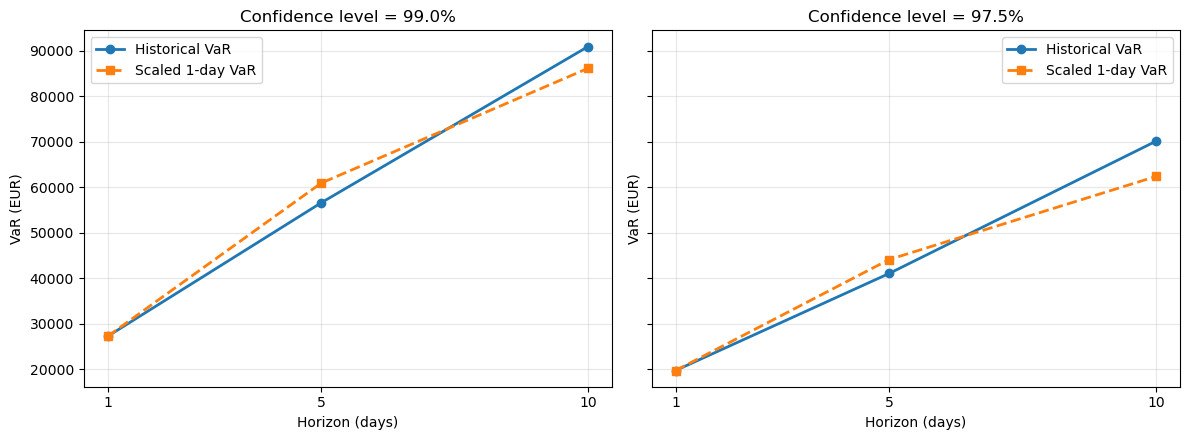

In [27]:
# Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, alpha in zip(axes, ALPHAS):
    sub = results_df[results_df["alpha"] == alpha].sort_values("horizon_days")

    ax.plot(sub["horizon_days"], sub["HS_VaR_eur"], marker="o", linewidth=2, label="Historical VaR")
    ax.plot(sub["horizon_days"], sub["SROT_VaR_eur"], marker="s", linewidth=2, linestyle="--",
            label="Scaled 1-day VaR")

    ax.set_title(f"Confidence level = {alpha*100:.1f}%")
    ax.set_xlabel("Horizon (days)")
    ax.set_ylabel("VaR (EUR)")
    ax.set_xticks([1, 5, 10])
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / "05_multiday_var_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

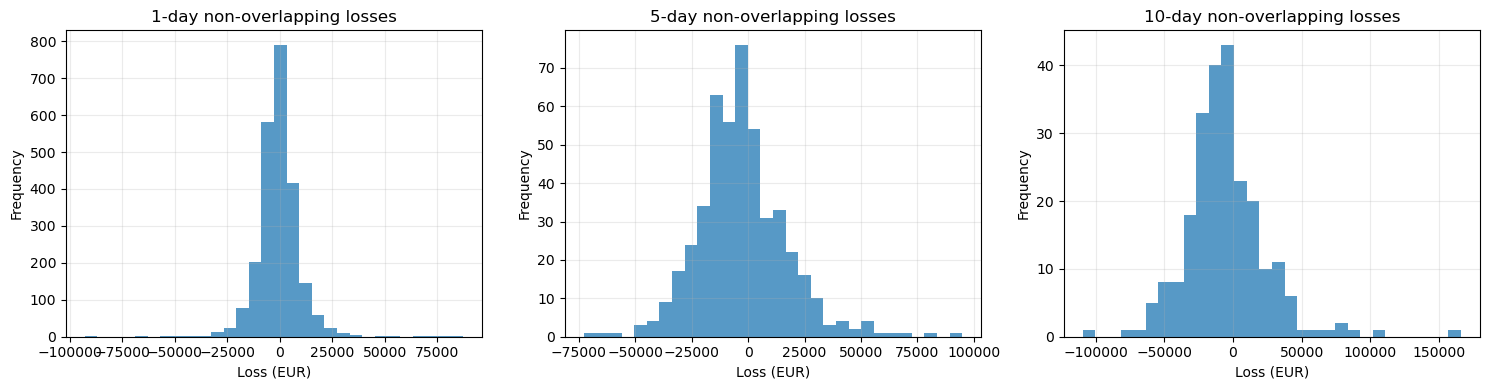

In [28]:
# Loss distributions by horizon
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, h in zip(axes, horizons):
    r_h = make_non_overlapping_returns(port_ret_1d, h)
    losses_h = -PORTFOLIO_VALUE * r_h

    ax.hist(losses_h, bins=30, alpha=0.75)
    ax.set_title(f"{h}-day non-overlapping losses")
    ax.set_xlabel("Loss (EUR)")
    ax.set_ylabel("Frequency")
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "05_multiday_loss_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# Task 7: Stress testing & shock scenarios

In [29]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_RETURNS = "data/returns_clean.csv"
DATA_PRICES  = "data/prices_clean.csv"
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

# ── Sample period ─────────────────────────────────────────────────────────────
SAMPLE_START = "2017-01-01"
SAMPLE_END   = "2026-03-31"

# ── Portfolio setup ────────────────────────────
PORTFOLIO_VALUE = 1_000_000
ALPHA_STRESS    = 0.99
TRADING_DAYS    = 252
LOAN_MOD_DUR    = 9.135099   # from 01_sid_data

WEIGHTS = {
    "ASML":      0.16,
    "SHELL":     0.08,
    "JPM_EUR":   0.24,
    "STOXX50":   0.08,
    "SP500_EUR": 0.24,
    "LOAN":      0.20,
}

ASSETS = list(WEIGHTS.keys())
w = np.array([WEIGHTS[a] for a in ASSETS])

assert abs(w.sum() - 1.0) < 1e-10


In [40]:
# Load data
prices = pd.read_csv(DATA_PRICES, index_col=0, parse_dates=True).sort_index()
prices = prices.loc[:SAMPLE_END]

raw_returns = pd.read_csv(DATA_RETURNS, index_col=0, parse_dates=True).sort_index()
raw_returns = raw_returns.loc[SAMPLE_START:SAMPLE_END]

# Convert to simple returns for portfolio risk calculations
simple_returns = pd.DataFrame(index=raw_returns.index)
for col in ASSETS:
    if col == "LOAN":
        simple_returns[col] = raw_returns[col]
    else:
        simple_returns[col] = np.expm1(raw_returns[col])

simple_returns = simple_returns.dropna()

current_date = prices.index.max()
current_prices = prices.loc[current_date].copy()

print(f"Current stress-test date: {current_date.date()}")
print(current_prices.to_frame("current_value"))

Current stress-test date: 2026-03-30
           current_value
ASML         1112.000000
SHELL          40.915001
JPM           283.769989
STOXX50      5541.790039
SP500        6343.720215
EURUSD          1.149201
EURIBOR3M       2.122000
JPM_EUR       246.928143
SP500_EUR    5520.115274


In [31]:
# Base portfolio value and base 1-day historical VaR
def historical_var_es(losses, alpha):
    losses = np.asarray(losses, dtype=float)
    losses = np.sort(losses)
    n = len(losses)

    K = int(np.ceil(n * alpha))
    frac = K - n * alpha

    var = losses[K - 1]
    es  = (losses[K:].sum() + frac * var) / (n * (1 - alpha))
    return var, es

base_port_ret = pd.Series(simple_returns[ASSETS].values @ w, index=simple_returns.index)
base_losses = -PORTFOLIO_VALUE * base_port_ret

base_var, base_es = historical_var_es(base_losses, ALPHA_STRESS)

print(f"Base 1-day historical VaR ({ALPHA_STRESS*100:.1f}%): €{base_var:,.0f}")
print(f"Base 1-day historical ES  ({ALPHA_STRESS*100:.1f}%): €{base_es:,.0f}")

Base 1-day historical VaR (99.0%): €27,243
Base 1-day historical ES  (99.0%): €41,792


In [32]:
# Stress testing functions

def equity_stress_multiplier(shock):
    """
    Shock is expressed as a relative move in price, e.g. +0.20 or -0.40.
    """
    return 1 + shock


def fx_stress_multiplier_eur_value(shock):
    """
    EURUSD is quoted as USD per EUR.
    
    If EURUSD rises, one euro buys more dollars, so USD assets are worth less in EUR.
    EUR value multiplier for USD assets = 1 / (1 + shock).
    """
    return 1 / (1 + shock)


def rate_stress_multiplier_loan(shock_abs):
    """
    Approximate loan value change from a parallel rate shift using modified duration:
        dP/P ≈ -D_mod * dy
    where shock_abs is in decimal, e.g. +0.02 for +2%.
    """
    return 1 - LOAN_MOD_DUR * shock_abs


def stressed_notionals_for_scenario(label, shock):
    """
    Returns stressed euro notionals by asset for a single-factor stress.
    """
    notionals = pd.Series({a: WEIGHTS[a] * PORTFOLIO_VALUE for a in ASSETS}, dtype=float)

    if label in ["ASML", "SHELL", "JPM_EUR", "STOXX50", "SP500_EUR"]:
        notionals[label] *= equity_stress_multiplier(shock)

    elif label == "EURUSD":
        # Only USD-origin assets translated into EUR are affected here:
        # JPM_EUR and SP500_EUR
        fx_mult = fx_stress_multiplier_eur_value(shock)
        notionals["JPM_EUR"]   *= fx_mult
        notionals["SP500_EUR"] *= fx_mult

    elif label == "EURIBOR3M":
        notionals["LOAN"] *= rate_stress_multiplier_loan(shock)

    else:
        raise ValueError("Unknown stress factor.")

    return notionals


In [41]:
# Scenario definitions and stressed P/L / VaR
stress_scenarios = []

# Equity and index shocks
for asset in ["ASML", "SHELL", "JPM_EUR", "STOXX50", "SP500_EUR"]:
    for shock in [-0.40, -0.20, 0.20, 0.40]:
        stress_scenarios.append({
            "factor_type": "Equity/Index",
            "factor": asset,
            "shock": shock
        })

# FX shock (major currency)
for shock in [-0.10, 0.10]:
    stress_scenarios.append({
        "factor_type": "FX",
        "factor": "EURUSD",
        "shock": shock
    })

# Interest-rate shock (absolute shift in yield)
for shock in [-0.03, -0.02, 0.02, 0.03]:
    stress_scenarios.append({
        "factor_type": "Rate",
        "factor": "EURIBOR3M",
        "shock": shock
    })

stress_scenarios = pd.DataFrame(stress_scenarios)
print(stress_scenarios)

     factor_type     factor  shock
0   Equity/Index       ASML  -0.40
1   Equity/Index       ASML  -0.20
2   Equity/Index       ASML   0.20
3   Equity/Index       ASML   0.40
4   Equity/Index      SHELL  -0.40
5   Equity/Index      SHELL  -0.20
6   Equity/Index      SHELL   0.20
7   Equity/Index      SHELL   0.40
8   Equity/Index    JPM_EUR  -0.40
9   Equity/Index    JPM_EUR  -0.20
10  Equity/Index    JPM_EUR   0.20
11  Equity/Index    JPM_EUR   0.40
12  Equity/Index    STOXX50  -0.40
13  Equity/Index    STOXX50  -0.20
14  Equity/Index    STOXX50   0.20
15  Equity/Index    STOXX50   0.40
16  Equity/Index  SP500_EUR  -0.40
17  Equity/Index  SP500_EUR  -0.20
18  Equity/Index  SP500_EUR   0.20
19  Equity/Index  SP500_EUR   0.40
20            FX     EURUSD  -0.10
21            FX     EURUSD   0.10
22          Rate  EURIBOR3M  -0.03
23          Rate  EURIBOR3M  -0.02
24          Rate  EURIBOR3M   0.02
25          Rate  EURIBOR3M   0.03


In [42]:
# Run stress tests
rows = []

base_notionals = pd.Series({a: WEIGHTS[a] * PORTFOLIO_VALUE for a in ASSETS}, dtype=float)

for _, sc in stress_scenarios.iterrows():
    factor = sc["factor"]
    shock  = sc["shock"]

    stressed_notionals = stressed_notionals_for_scenario(factor, shock)

    # Immediate mark-to-market P/L from the shock
    pnl_now = stressed_notionals.sum() - base_notionals.sum()

    # Recompute 1-day stressed historical loss distribution
    # by applying the same daily simple returns to stressed notionals
    stressed_losses = -(
        simple_returns[ASSETS].mul(stressed_notionals.values, axis=1).sum(axis=1)
    )

    stressed_var, stressed_es = historical_var_es(stressed_losses, ALPHA_STRESS)

    rows.append({
        "factor_type": sc["factor_type"],
        "factor": factor,
        "shock": shock,
        "instant_PnL_eur": pnl_now,
        "stressed_VaR_eur": stressed_var,
        "stressed_ES_eur": stressed_es,
        "base_VaR_eur": base_var,
        "delta_VaR_eur": stressed_var - base_var,
        "delta_ES_eur": stressed_es - base_es,
    })

stress_results = pd.DataFrame(rows).sort_values(["factor_type", "factor", "shock"])
print(stress_results.round(0))

     factor_type     factor  shock  instant_PnL_eur  stressed_VaR_eur  \
0   Equity/Index       ASML   -0.0         -64000.0           24423.0   
1   Equity/Index       ASML   -0.0         -32000.0           25378.0   
2   Equity/Index       ASML    0.0          32000.0           28737.0   
3   Equity/Index       ASML    0.0          64000.0           30020.0   
8   Equity/Index    JPM_EUR   -0.0         -96000.0           23857.0   
9   Equity/Index    JPM_EUR   -0.0         -48000.0           25834.0   
10  Equity/Index    JPM_EUR    0.0          48000.0           28693.0   
11  Equity/Index    JPM_EUR    0.0          96000.0           30117.0   
4   Equity/Index      SHELL   -0.0         -32000.0           26625.0   
5   Equity/Index      SHELL   -0.0         -16000.0           26971.0   
6   Equity/Index      SHELL    0.0          16000.0           27515.0   
7   Equity/Index      SHELL    0.0          32000.0           28075.0   
16  Equity/Index  SP500_EUR   -0.0         -96000.0

In [43]:
# Cleaner formatted tables
table_stress = stress_results.copy()

table_stress["shock_label"] = table_stress.apply(
    lambda x: f"{x['shock']*100:+.0f}%" if x["factor"] != "EURIBOR3M" else f"{x['shock']*100:+.0f}pp",
    axis=1
)

table_stress = table_stress[[
    "factor_type", "factor", "shock_label",
    "instant_PnL_eur", "stressed_VaR_eur", "stressed_ES_eur",
    "delta_VaR_eur", "delta_ES_eur"
]]

print(table_stress.round(0))

     factor_type     factor shock_label  instant_PnL_eur  stressed_VaR_eur  \
0   Equity/Index       ASML        -40%         -64000.0           24423.0   
1   Equity/Index       ASML        -20%         -32000.0           25378.0   
2   Equity/Index       ASML        +20%          32000.0           28737.0   
3   Equity/Index       ASML        +40%          64000.0           30020.0   
8   Equity/Index    JPM_EUR        -40%         -96000.0           23857.0   
9   Equity/Index    JPM_EUR        -20%         -48000.0           25834.0   
10  Equity/Index    JPM_EUR        +20%          48000.0           28693.0   
11  Equity/Index    JPM_EUR        +40%          96000.0           30117.0   
4   Equity/Index      SHELL        -40%         -32000.0           26625.0   
5   Equity/Index      SHELL        -20%         -16000.0           26971.0   
6   Equity/Index      SHELL        +20%          16000.0           27515.0   
7   Equity/Index      SHELL        +40%          32000.0        

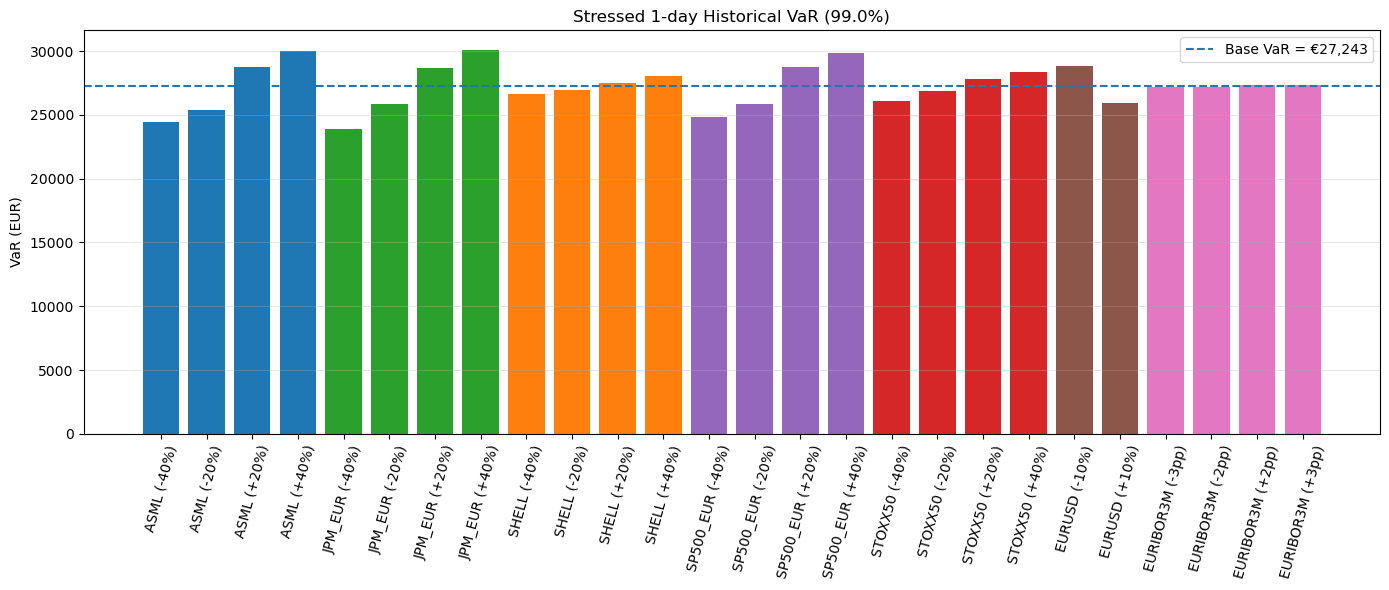

In [44]:
# Plot stressed VaR vs base VaR
plot_df = stress_results.copy()
plot_df["scenario"] = plot_df.apply(
    lambda x: f"{x['factor']} ({x['shock']*100:+.0f}%)" if x["factor"] != "EURIBOR3M"
    else f"{x['factor']} ({x['shock']*100:+.0f}pp)",
    axis=1
)

# Assign distinct colors per stressed factor
factor_colors = {
    "ASML": "#1f77b4",
    "SHELL": "#ff7f0e",
    "JPM_EUR": "#2ca02c",
    "STOXX50": "#d62728",
    "SP500_EUR": "#9467bd",
    "EURUSD": "#8c564b",
    "EURIBOR3M": "#e377c2",
}
bar_colors = plot_df["factor"].map(factor_colors).fillna("#7f7f7f")

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(plot_df["scenario"], plot_df["stressed_VaR_eur"], color=bar_colors)
ax.axhline(base_var, linestyle="--", linewidth=1.5, label=f"Base VaR = €{base_var:,.0f}")
ax.set_title(f"Stressed 1-day Historical VaR ({ALPHA_STRESS*100:.1f}%)")
ax.set_ylabel("VaR (EUR)")
ax.tick_params(axis="x", rotation=75)
ax.grid(True, axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / "06_stressed_var_barplot.png", dpi=150, bbox_inches="tight")
plt.show()

In [45]:
# Sort by most severe impact

worst_pnl = stress_results.sort_values("instant_PnL_eur").head(10)
worst_var = stress_results.sort_values("stressed_VaR_eur", ascending=False).head(10)

print("Worst immediate mark-to-market scenarios")
print(worst_pnl[["factor_type", "factor", "shock", "instant_PnL_eur"]].round(0))

print("Highest stressed VaR scenarios")
print(worst_var[["factor_type", "factor", "shock", "stressed_VaR_eur", "delta_VaR_eur"]].round(0))


Worst immediate mark-to-market scenarios
     factor_type     factor  shock  instant_PnL_eur
16  Equity/Index  SP500_EUR   -0.0         -96000.0
8   Equity/Index    JPM_EUR   -0.0         -96000.0
0   Equity/Index       ASML   -0.0         -64000.0
25          Rate  EURIBOR3M    0.0         -54811.0
9   Equity/Index    JPM_EUR   -0.0         -48000.0
17  Equity/Index  SP500_EUR   -0.0         -48000.0
21            FX     EURUSD    0.0         -43636.0
24          Rate  EURIBOR3M    0.0         -36540.0
1   Equity/Index       ASML   -0.0         -32000.0
4   Equity/Index      SHELL   -0.0         -32000.0
Highest stressed VaR scenarios
     factor_type     factor  shock  stressed_VaR_eur  delta_VaR_eur
11  Equity/Index    JPM_EUR    0.0           30117.0         2874.0
3   Equity/Index       ASML    0.0           30020.0         2777.0
19  Equity/Index  SP500_EUR    0.0           29831.0         2589.0
20            FX     EURUSD   -0.0           28837.0         1595.0
2   Equity/Index